---
Title: "Economic Impacts of Migration"
---

<!-- You have to develop your own headline structure. -->

## Headline 1
Analysis of Migration and Remittance Dynamics in Nigeria (2000–2024): 
## Headline 2
Scaling,
Correlation, and 
Policy Efficiency

In [ ]:
#Data Cleaning and Analysis (Nigeria to UK Migration Stock)

import pandas as pd
import os

# File path
file_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\Part 3\Economic Impact\Migration stock\raw_migration_stock.xlsx"

# Read Table 1
df = pd.read_excel(file_path, sheet_name="Table 1", skiprows=10)

# Clean column names
df.columns = df.columns.str.strip()

# Strip spaces in name columns
df['Region, development group, country or area of origin'] = (
    df['Region, development group, country or area of origin']
    .astype(str).str.strip()
)

df['Region, development group, country or area of destination'] = (
    df['Region, development group, country or area of destination']
    .astype(str).str.strip()
)

# Automatically find codes for Nigeria and UK
nigeria_code = df.loc[
    df['Region, development group, country or area of origin']
    .str.contains('Nigeria', case=False, na=False),
    'Location code of origin'
].unique()[0]

uk_code = df.loc[
    df['Region, development group, country or area of destination']
    .str.contains('United Kingdom', case=False, na=False),
    'Location code of destination'
].unique()[0]

print("Nigeria code:", nigeria_code)
print("UK code:", uk_code)

# Filter row for Nigeria as origin
nigeria_row = df[df['Location code of origin'] == nigeria_code]

# Identify all year columns 2000–2026
year_cols = [
    col for col in df.columns
    if isinstance(col, str) and any(col.startswith(str(year)) for year in range(2000, 2027))
]

# Extract migration counts for UK
uk_col_candidates = [c for c in df.columns if str(uk_code) in str(c)]

if uk_col_candidates:
    uk_col = uk_col_candidates[0]
    nigeria_to_uk = nigeria_row[year_cols + [uk_col]]
else:
    nigeria_to_uk = nigeria_row[year_cols]

# output folder + filename
output_folder = r"c:\Users\ZIZIPHO\Desktop\DataScienceLab"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "nigeria_to_uk_migration_2000_2026.csv")

# Save to CSV
nigeria_to_uk.to_csv(output_path, index=False)

print("Filtered Nigeria → UK migration (2000–2026) saved at:", output_path)
print(nigeria_to_uk)

Nigeria code: 566
UK code: 826
Filtered Nigeria → UK migration (2000–2026) saved at: c:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_2000_2026.csv
       2000.1  2005.1  2010.1  2015.1  2020.1   2024.1  2000.2  2005.2  \
84     298175  426869  536809  722576  947270  1099316  243965  337122   
370    144478  184659  211165  292058  353023   392744  111025  141490   
597     17467   22308   23844   28607   36440    52288   13837   16128   
776       408     378     380     502     471      462     380     331   
931      2017    2680    3150    3744    5003     5358     517     648   
...       ...     ...     ...     ...     ...      ...     ...     ...   
25881    4525    7580   14990   25136   38980    56121    3557    6314   
26093   69664   96515  117513  168524  240635   285451   55839   71206   
26239    1113    1565    2741    5060    8212    11262     699    1035   
26495    1113    1565    2741    5060    8212    11262     699    1035   
26746    1113    1565  

In [ ]:
# Total migration from Nigeria to the UK (2000–2026)

import pandas as pd

# Load your filtered CSV
df = pd.read_csv(r"c:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_2000_2026.csv")

# Sum across all rows to get total migration per year
total_migration = df.sum(axis=0)

# make a clean table
clean_df = pd.DataFrame({
    'Year': total_migration.index,
    'Number of Migrants': total_migration.values
})

clean_df.to_csv(r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_to_uk_migration_totals_2000_2004.csv", index=False)

print(clean_df)

      Year  Number of Migrants
0   2000.1             2935764
1   2005.1             4103056
2   2010.1             5058710
3   2015.1             6824936
4   2020.1             8817306
5   2024.1            10177871
6   2000.2             2372601
7   2005.2             3222717
8   2010.2             4085094
9   2015.2             5992138
10  2020.2             7684414
11  2024.2             9192164


In [16]:
import sys
!{sys.executable} -m pip install xlrd

  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
#Total remittances from Nigeria to the UK (2000-2024)

import pandas as pd

# File path
file_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\Part 3\Economic Impact\Remittances\raw_remittances.xls"

# Read Excel (skip metadata rows)
df = pd.read_excel(file_path, sheet_name=0, skiprows=3)

# Check columns
print("Columns in dataset:")
print(df.columns)

# The country name column (column 4)
country_col = df.columns[0]   # usually "Country Name"

# Filter for Nigeria
nigeria_df = df[df[country_col].str.contains("Nigeria", case=False, na=False)]

# Extract year columns from 2000 to 2024
year_cols = [col for col in df.columns if str(col).isdigit() and 2000 <= int(col) <= 2024]

# Keep only Nigeria and the selected years
result = nigeria_df[[country_col] + year_cols]

# Save cleaned CSV
output_path = r"C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_remittances_2000_2024.csv"
result.to_csv(output_path, index=False)

print("Nigeria remittances extracted successfully.")
print("Saved to:", output_path)

# Preview
print(result)

Columns in dataset:
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='str')
Nigeria remittances extracted successfully.
Saved to: C:\Users\ZIZIPHO\Desktop\DataScienceLab\nigeria_remittances_2000_2024.csv
    Country Name          2000           2001           2002          2003  \
174      Nigeria  1.052142e+06  593358.431196  903977.979981  1.156224e+07   

             200

   Year  total_remittances  number_of_migrants
0  2000       1.052142e+06               83822
1  2005       6.803027e+07              125003
2  2010       4.747469e+07              189847
3  2015       1.035451e+09              236603
4  2020       9.210166e+07              286251
Index(['Year', 'total_remittances', 'number_of_migrants'], dtype='str')

Correlation between Remittances and Migrants: 0.22


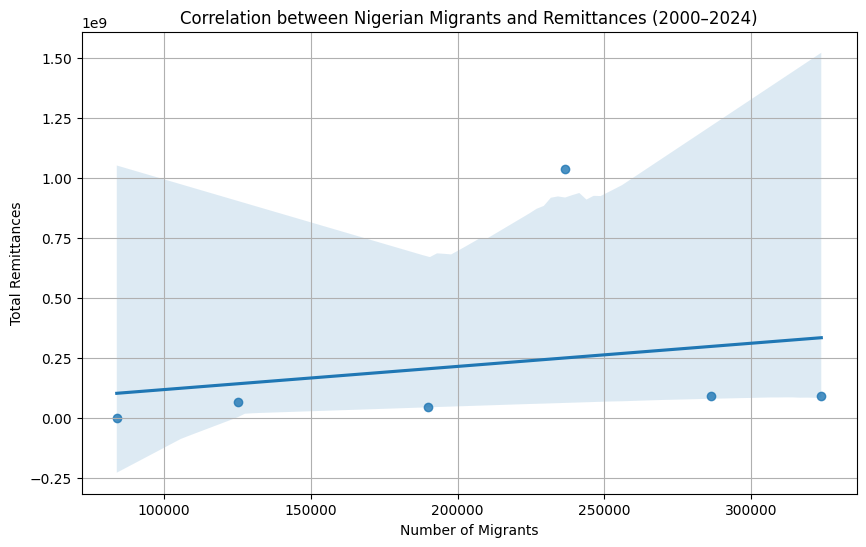

In [ ]:
#Correlation between Nigerian Migrants and Remittances (2000–2024)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File path (your merged dataset)
file_path = r"C:\Users\ZIZIPHO\Desktop\MSc Data Engineering\Python Programming for DE\Tutorials\Fundamentals_PythonNtshatsha\DataScienceLab_Migration\data_processed\merged_migration_remittances 1(in).csv"

# Load the merged data
df = pd.read_csv(file_path)

# Inspect data
print(df.head())
print(df.columns)

# Clean column names (strip spaces and convert to lowercase with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Make sure correct data types
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['total_remittances'] = pd.to_numeric(df['total_remittances'], errors='coerce')
df['number_of_migrants'] = pd.to_numeric(df['number_of_migrants'], errors='coerce')

# Drop missing values
df = df.dropna()

# Correlation
correlation = df['total_remittances'].corr(df['number_of_migrants'])
print(f"\nCorrelation between Remittances and Migrants: {correlation:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df['number_of_migrants'], 
    y=df['total_remittances'], 
    marker='o'
)

plt.title('Correlation between Nigerian Migrants and Remittances (2000–2024)')
plt.xlabel('Number of Migrants')
plt.ylabel('Total Remittances')
plt.grid(True)
plt.show()

The graph shows a weak positive relationship between the number of migrants and total remittances. Each point represents a specific year, plotting migration against remittance inflows. The upward-sloping trend line suggests that remittances tend to increase as migration rises. However, the low correlation coefficient (0.22) indicates that this relationship is not strong. The wide spread of points and the large confidence interval suggest that other factors, beyond migration, significantly influence remittance flows.

Reason for the spike in 2015?

In 2015:
Nigeria faced falling oil prices (major income source) and coursed Economic uncertainty.
Global evidence shows that low oil prices and economic stress affect remittance behavior.
Reference: International Monetary Fund. (2016). IMF Executive Board Concludes 2016 Article IV Consultation with Nigeria. IMF

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'total_remittances': [1.052142e6, 6.803027e7, 4.747469e7, 1.035451e9, 9.210166e7],
    'number_of_migrants': [83822, 125003, 189847, 236603, 286251]
}

df = pd.DataFrame(data)

# scale
scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[['remittances_scaled', 'migrants_scaled']] = scaler.fit_transform(
    df[['total_remittances', 'number_of_migrants']]
)

#policy index (weighted)
df_scaled['Policy_Index'] = (
    0.7 * df_scaled['remittances_scaled']
    - 0.3 * df_scaled['migrants_scaled']
)

print(df_scaled)


   Year  total_remittances  number_of_migrants  remittances_scaled  \
0  2000       1.052142e+06               83822            0.000000   
1  2005       6.803027e+07              125003            0.064751   
2  2010       4.747469e+07              189847            0.044879   
3  2015       1.035451e+09              236603            1.000000   
4  2020       9.210166e+07              286251            0.088022   

   migrants_scaled  Policy_Index  
0         0.000000      0.000000  
1         0.203434     -0.015705  
2         0.523764     -0.125714  
3         0.754739      0.473578  
4         1.000000     -0.238385  


The policy index assigns a weight of 70% to remittances and 30% to migration, reflecting the assumption that economic gains are more important than the costs associated with human migration. The negative sign for migration indicates that higher migration is treated as a loss.

The results show that 2015 achieved the highest policy efficiency, as strong remittance inflows outweighed the costs of migration. In contrast, 2020 recorded the lowest score, indicating that high migration was not matched by sufficient financial returns. Overall, the findings suggest that migration only contributes positively to policy outcomes when it generates substantial economic benefits.

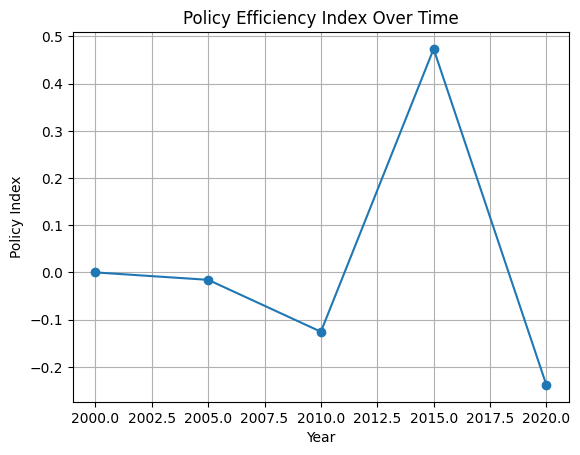

In [18]:
import matplotlib.pyplot as plt

plt.plot(df_scaled['Year'], df_scaled['Policy_Index'], marker='o')
plt.title("Policy Efficiency Index Over Time")
plt.xlabel("Year")
plt.ylabel("Policy Index")
plt.grid()
plt.show()